# 10. 단어 임베딩 — 단어에 '의미'를 담기

지금까지 단어를 **원-핫**으로 다뤘다. `king` = `[0,1,0,0,...]`, `queen` = `[0,0,0,1,...]`.
그런데 원-핫에는 큰 문제가 있다:

- 모든 단어가 **서로 완전히 독립**이다. `king`과 `queen`이 얼마나 비슷한지 **전혀 알 수 없다**.
- 단어가 1만 개면 벡터도 1만 차원 — **낭비가 심하다**.

**단어 임베딩(word embedding)** 은 단어를 **몇 차원의 조밀한 실수 벡터**로 바꾼다.
그리고 그 벡터 공간에서 **의미가 비슷한 단어는 가까이** 놓이도록 학습한다.

> `king`과 `queen`은 가까이, `king`과 `apple`은 멀리.
> 유명한 예: `king - man + woman ≈ queen` (벡터 연산으로 의미가 계산된다!)

이 노트북에서 배우는 것:
1. **Word2Vec의 원리** — 주변 단어로 중심 단어를 맞히며 임베딩을 학습
2. **2차원 시각화** — 학습된 단어 벡터를 평면에 찍어보기
3. **IMDB 감성분석** — 임베딩을 실전 텍스트 분류에 적용


## 1부. Word2Vec 맛보기 — 단어를 2차원에 배치하기

**핵심 아이디어**: "비슷한 문맥에 나오는 단어는 비슷한 뜻이다."

> "왕(king)은 용감한(brave) 남자(man)다. 여왕(queen)은 아름다운(beautiful) 여자(woman)다."

이 문장에서 각 단어의 **주변 단어**를 보고, 단어 벡터를 학습한다.
여기서는 원리를 보기 위해 **AutoEncoder 구조**(노트북 05)로 단어를 2차원으로 압축한다.

### 1-1. 문장 준비와 전처리

노트북 09에서 배운 걸 쓴다: 소문자화, 토큰화, 불용어·문장부호 제거.


In [1]:
import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
nltk.download('punkt_tab')

txt = 'King is a brave man. Queen is a beautiful woman.'
sw = set(stopwords.words('english'))

# 소문자 → 토큰화 → 불용어/문장부호 제거
wrdlst = [wd for wd in word_tokenize(txt.lower())
          if wd not in sw and wd.isalpha()]
print(wrdlst)


['king', 'brave', 'man', 'queen', 'beautiful', 'woman']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


### 1-2. 단어 사전 만들기

노트북 08의 `Tokenizer`로 각 단어에 번호를 매긴다. 6개 단어 → 번호 1~6.


In [2]:
from tensorflow.keras.preprocessing.text import Tokenizer

tkn = Tokenizer()
tkn.fit_on_texts(wrdlst)
print("단어→번호:", tkn.word_index)


단어→번호: {'king': 1, 'brave': 2, 'man': 3, 'queen': 4, 'beautiful': 5, 'woman': 6}


### 1-3. 학습 데이터 — (주변 단어 → 중심 단어)

Word2Vec의 핵심 트릭. 각 단어를 **바로 옆 단어와 짝지어** 학습 데이터를 만든다.

```
king  brave  man  queen  beautiful  woman
  └────┘      → "brave 옆엔 king이 온다"
       └───┘  → "man 옆엔 brave가 온다"
```

이렇게 **"옆에 같이 나오는 단어"** 쌍을 모으면, 모델은 "어떤 단어들이 서로 이웃인지"를 배운다.
이웃인 단어끼리는 벡터 공간에서 가까워진다.

- `x_data` : 입력 단어 (원-핫)
- `y_data` : 그 옆 단어 (원-핫)


In [3]:
from tensorflow.keras.utils import to_categorical

vocab = len(tkn.word_index) + 1     # +1은 0번 패딩 자리

# 인접한 단어 쌍 만들기 (앞뒤 이웃)
pairs = []
for i in range(len(wrdlst)):
    if i > 0:
        pairs.append((wrdlst[i], wrdlst[i-1]))   # 앞 이웃
    if i < len(wrdlst) - 1:
        pairs.append((wrdlst[i], wrdlst[i+1]))   # 뒤 이웃

x_data, y_data = [], []
for center, context in pairs:
    x_data.append(to_categorical(tkn.word_index[center], vocab))
    y_data.append(to_categorical(tkn.word_index[context], vocab))
x_data = np.array(x_data)
y_data = np.array(y_data)
print("학습 쌍:", len(pairs), "| x:", x_data.shape)


학습 쌍: 10 | x: (10, 7)


### 1-4. 인코더-디코더로 2차원 임베딩 학습

노트북 05의 AutoEncoder와 같은 구조다. 단어(원-핫)를 **2차원으로 압축**했다가 다시 펼친다.

```
입력 단어(7차원 원-핫) → Dense(8) → Dense(2)  ← 이 2차원이 단어 임베딩!
                                     → Dense(8) → Dense(7, softmax) → 옆 단어 예측
```

- **인코더의 출력(2차원)** 이 바로 **단어 벡터**다.
- "옆 단어를 맞히도록" 학습하면, 같이 나오는 단어들의 2차원 벡터가 가까워진다.
- 출력이 "어떤 단어인가"를 맞히는 분류라 `softmax` + `categorical_crossentropy`.


In [4]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense

encoder = Sequential(name='encoder')
encoder.add(Input(shape=(vocab,)))
encoder.add(Dense(8, activation='relu'))
encoder.add(Dense(2))                       # ← 2차원 임베딩

decoder = Sequential(name='decoder')
decoder.add(Input(shape=(2,)))
decoder.add(Dense(8, activation='relu'))
decoder.add(Dense(vocab, activation='softmax'))

inp = Input(shape=(vocab,))
model = Model(inp, decoder(encoder(inp)))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(x_data, y_data, epochs=500, verbose=0)
print("학습 완료")


학습 완료


### 1-5. 단어 임베딩 시각화 ★

각 단어를 인코더에 넣어 2차원 벡터를 얻고, 평면에 찍는다.
**의미가 비슷한 단어끼리 가까이 모이는지** 확인한다.


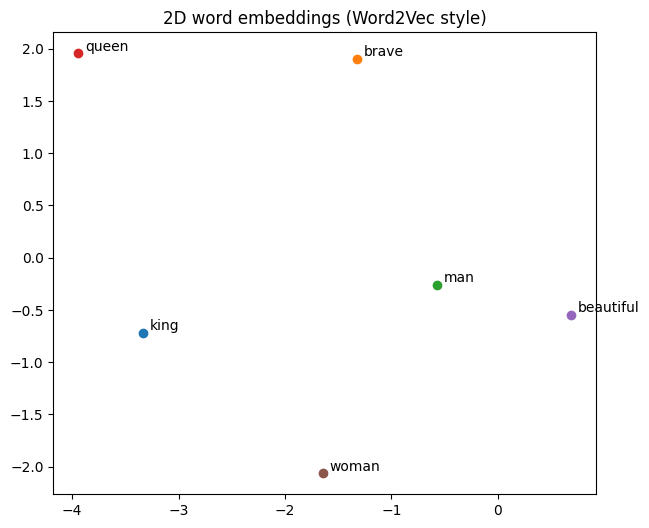

In [5]:
import matplotlib.pyplot as plt

# 각 단어의 2차원 임베딩 구하기
x_test = np.array([to_categorical(i, vocab) for i in tkn.word_index.values()])
embed = encoder.predict(x_test, verbose=0)

plt.figure(figsize=(7, 6))
for i, word in enumerate(tkn.word_index):
    x, y = embed[i]
    plt.scatter(x, y)
    plt.annotate(word, (x, y), xytext=(5, 2), textcoords='offset points')
plt.title('2D word embeddings (Word2Vec style)')
plt.show()


## 2부. IMDB 영화 리뷰 감성분석 — 실전 텍스트 분류

1부는 6단어짜리 장난감이었다. 이번엔 **진짜 데이터**다.

**IMDB 데이터셋**: 영화 리뷰 5만 건(학습 2.5만 / 테스트 2.5만).
각 리뷰에 **긍정(1) / 부정(0)** 라벨이 달려 있다. 우리 목표는 리뷰 텍스트로 긍부정을 맞히는 것.

Keras가 이 데이터를 **이미 숫자로 인코딩해서** 제공한다 — 각 단어가 빈도순 번호로 바뀌어 있다.

### 2-1. 데이터 불러오기

`num_words=10000` : 가장 자주 나오는 상위 1만 단어만 쓴다 (드문 단어는 무시).


In [6]:
from tensorflow.keras.datasets import imdb

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=10000)
print("학습:", x_train.shape, "| 테스트:", x_test.shape)
print("첫 리뷰 길이:", len(x_train[0]), "| 라벨:", y_train[0])
print("첫 리뷰 앞부분:", x_train[0][:12])


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
학습: (25000,) | 테스트: (25000,)
첫 리뷰 길이: 218 | 라벨: 1
첫 리뷰 앞부분: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468]


### 2-2. 숫자를 단어로 되돌려 보기

리뷰가 숫자라 사람이 못 읽는다. `imdb.get_word_index()`로 **번호→단어** 사전을 만들어 복원한다.

주의: 인덱스가 **3만큼 밀려 있다.** 0,1,2는 특수 토큰(패딩·시작·미지)이라, 실제 단어는 3을 빼야 맞다.


In [7]:
word_index = imdb.get_word_index()
idx2word = {idx + 3: wd for wd, idx in word_index.items()}
idx2word[0], idx2word[1], idx2word[2] = '<pad>', '<start>', '<unk>'

decoded = ' '.join(idx2word.get(i, '?') for i in x_train[0])
print("첫 리뷰 (복원):", decoded[:300])
print("\n라벨:", y_train[0], "(1=긍정, 0=부정)")


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
첫 리뷰 (복원): <start> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <unk> is an amazing actor and now the same being director <unk> father came from the same scottish island as myself so i loved the

라벨: 1 (1=긍정, 0=부정)


### 2-3. 길이 맞추기 (pad_sequences)

리뷰마다 길이가 다르다. 신경망은 고정 크기 입력만 받으므로 **길이를 통일**한다 (노트북 08).

`maxlen=200` : 200단어로 자르거나 채운다. 짧으면 앞에 0(패딩)을 넣는다.


In [8]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

x_train_pad = pad_sequences(x_train, maxlen=200)
x_test_pad = pad_sequences(x_test, maxlen=200)
print("패딩 후:", x_train_pad.shape)     # (25000, 200)


패딩 후: (25000, 200)


### 2-4. Embedding 층 — 임베딩을 모델 안에서 학습

1부에서는 임베딩을 직접 만들었다. 실전에서는 **`Embedding` 층**이 이걸 자동으로 한다.

```
Input(200)                          # 200개 단어 번호
  → Embedding(10000, 32)            # 각 번호를 32차원 벡터로 (임베딩 학습!)
  → LSTM(32)                        # 시퀀스를 읽어 문맥 파악 (노트북 08)
  → Dense(1, sigmoid)               # 긍정 확률
```

- **`Embedding(10000, 32)`** : 1만 단어 각각을 **32차원 벡터**로. 이 벡터들이 학습으로 정해진다
  (1부에서 2차원으로 했던 걸, 여기선 32차원으로 자동화).
- **`LSTM`** : 리뷰를 단어 순서대로 읽으며 "긍정적 흐름인지 부정적 흐름인지" 파악 (노트북 08의 그 LSTM).
- 이진 분류라 `Dense(1, sigmoid)` + `binary_crossentropy`.


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Input

model = Sequential()
model.add(Input(shape=(200,)))
model.add(Embedding(10000, 32))
model.add(LSTM(32))
model.add(Dense(1, activation='sigmoid'))
model.summary()

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
hist = model.fit(x_train_pad, y_train,
                 validation_data=(x_test_pad, y_test),
                 epochs=3, batch_size=128)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,353 (1.25 MB)

 Trainable params: 328,353 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.7331 - loss: 0.5372 - val_accuracy: 0.8356 - val_loss: 0.3821
Epoch 2/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8839 - loss: 0.2934 - val_accuracy: 0.8703 - val_loss: 0.3152
Epoch 3/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9228 - loss: 0.2087 - val_accuracy: 0.8701 - val_loss: 0.3231


### 2-5. 결과 확인 + 직접 예측

학습 곡선을 보고, 실제 리뷰 몇 개를 예측해본다.


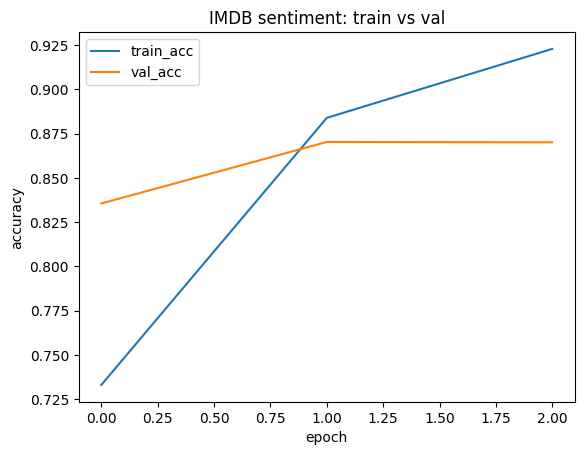


리뷰: please give this one a miss br br and the rest of the cast rendered terrible performances the show is flat flat flat br br i don't know how michael ma...
  실제: 부정 | 예측 확률: 0.305 (부정)

리뷰: this film requires a lot of patience because it focuses on mood and character development the plot is very simple and many of the scenes take place on...
  실제: 긍정 | 예측 확률: 0.988 (긍정)

리뷰: many animation buffs consider the great forgotten genius of one special branch of the art puppet animation which he invented almost single and as it h...
  실제: 긍정 | 예측 확률: 0.960 (긍정)


In [10]:
import matplotlib.pyplot as plt

plt.plot(hist.history['accuracy'], label='train_acc')
plt.plot(hist.history['val_accuracy'], label='val_acc')
plt.xlabel('epoch'); plt.ylabel('accuracy'); plt.legend()
plt.title('IMDB sentiment: train vs val')
plt.show()

# 테스트 리뷰 3개 예측
pred = model.predict(x_test_pad[:3], verbose=0)
for i in range(3):
    review = ' '.join(idx2word.get(w, '?') for w in x_test[i] if w > 2)
    print(f"\n리뷰: {review[:150]}...")
    print(f"  실제: {'긍정' if y_test[i]==1 else '부정'} | "
          f"예측 확률: {pred[i][0]:.3f} ({'긍정' if pred[i][0]>0.5 else '부정'})")


## 정리 — 단어 임베딩

### 1부. Word2Vec 2D 시각화 ★

6단어를 2차원에 찍은 결과, **문맥이 비슷한 단어가 가까이** 모였다:

- **king, queen 이 둘 다 왼쪽(x ≈ -3.3, -3.9)** 에 모였다. 원문에서 둘 다 문장 맨 앞(주어) 자리라
  **앞뒤 이웃이 비슷**하기 때문이다. Word2Vec의 핵심 — "비슷한 문맥의 단어는 가까이" — 이 실제로 나타났다.
- man, beautiful 은 오른쪽, brave·woman 은 위아래로 흩어졌다.

> ⚠️ 솔직하게: 데이터가 **2문장 6단어뿐**이라, "king-man(남성) vs queen-woman(여성)" 같은
> 완벽한 의미 군집까지는 안 나온다. 임베딩은 **문맥(옆에 뭐가 오는지)** 으로 배우는데,
> 여기선 king/queen의 문맥이 거의 같아서(둘 다 "___ is ...") 오히려 가까워진 것이다.
> 진짜 의미 관계(`king - man + woman ≈ queen`)를 보려면 수백만 문장이 필요하다.

**그래도 원리는 확인됐다**: 원-핫(모든 단어가 독립)과 달리, 임베딩은 단어 사이의 **관계를 2차원에 담아낸다.**

### 2부. IMDB 감성분석

실전 데이터로 임베딩을 적용했다. 실행 결과:

| | 학습 정확도 | 검증 정확도 |
|---|---|---|
| 에폭 1 | 0.733 | 0.836 |
| 에폭 2 | 0.884 | **0.870** ← 최고 |
| 에폭 3 | 0.923 | 0.870 |

- **검증 정확도 약 0.87** — 영화 리뷰 5만 건으로 긍부정을 87% 맞힌다.
- 에폭 3에서 학습 정확도는 0.92로 오르는데 검증은 0.87에 멈췄다 — **살짝 과적합 시작**(노트북 01의 그 신호).
- 실제 예측도 정확했다:
  - "terrible performances ... flat flat flat" → **부정 0.305** ✓
  - "focuses on mood and character development" → **긍정 0.988** ✓
  - "great forgotten genius ... puppet animation" → **긍정 0.960** ✓

핵심 구조: **`Embedding`(단어→32차원 벡터) → `LSTM`(순서대로 읽어 문맥 파악) → `Dense`(긍부정)**.
1부에서 손으로 만든 임베딩을, `Embedding` 층이 자동으로 학습한 것이다.

---

| 개념 | 핵심 |
|---|---|
| **원-핫의 한계** | 모든 단어가 독립, 유사도 표현 불가, 차원 낭비 |
| **단어 임베딩** | 단어를 조밀한 실수 벡터로. 비슷한 단어는 가까이 |
| **Word2Vec 원리** | 옆에 나오는 단어를 맞히며 학습 (문맥이 곧 의미) |
| **Embedding 층** | 모델 안에서 임베딩을 자동 학습 (`Embedding(단어수, 차원)`) |
| **IMDB 감성분석** | Embedding + LSTM으로 리뷰 긍부정 87% |

---

## NLP 시리즈(08~10)를 마치며

| # | 주제 | 남긴 것 |
|---|---|---|
| 08 | Seq2Seq | 문장→문장 번역, Tokenizer·pad_sequences, Bidirectional·LSTM |
| 09 | 텍스트 전처리 | 표제어·어간·불용어(영어), KoNLPy 형태소(한국어) |
| 10 | 단어 임베딩 | 단어를 의미 벡터로, Word2Vec 원리, IMDB 감성분석 |

**텍스트를 다루는 전체 흐름**이 완성됐다:

```
원문 텍스트
  → 전처리 (09: 토큰화·표제어·형태소)
  → 숫자로 (08: Tokenizer·pad_sequences)
  → 의미 벡터로 (10: Embedding)
  → 모델 (RNN·LSTM: 06·08)
  → 예측 (번역·분류)
```

이 다음은 **Transformer**(GPT·BERT의 기반)로 이어진다 — RNN의 "순서대로 읽기"를
"한 번에 전체를 보되 중요한 곳에 집중(attention)"으로 바꾼 것이다.
하지만 그 출발점은 이 시리즈에서 배운 것들 — 임베딩, 시퀀스, 문맥 — 그대로다.

수고하셨습니다. 🎉